# NumPy Basics: Arrays and Vectorized Computation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


- *array-based* operations for data cleaning, filtering, and transformation
- sorting, set operations
- linear algebra 
- need to use with pandas

### Arrays

In [2]:
data = np.array([[1.5, -0.1,3], [0,-3,6.5]])
data


array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

NumPy can do 1D (a single list of numbers — like a vector), 
2D (a grid — like a spreadsheet), 
3D (a cube — like a stack of grids), and beyond. 
-> For your work, 1D arrays will be time-series signals (ECG), 2D arrays will be tables of vitals or grayscale images, and 3D/4D arrays will be color images or batches of images.
data.shape = (row, column)
dtype (data type). float64 is a number with a decimal point, stored using 64 bits of memory. It's NumPy's default for any array containing decimal numbers.

In [3]:
data * 10
data + data
data.shape
data.dtype

dtype('float64')

In [4]:
data1 = [6, 7.5, 8, 0, 1]
arr1 = np.array(data1)
arr1

array([6. , 7.5, 8. , 0. , 1. ])

In [5]:
data2 = [[1, 2, 3, 4, 5], [6, 7, 8, 9, 10]]
arr2=np.array(data2)
arr2

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [6]:
arr2.ndim
arr2.shape
arr2.dtype

dtype('int64')

- np allows operations like matrices through vectorization
- between same size yield Boolean arrays 
- array indexing = selecting parts of data

In [7]:
arr = np.arange(10)
arr
arr[5]
arr[5:8]
arr[5:8] = 12
arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

In [8]:
arr_slice = arr[5:8]
arr_slice
arr_slice[1]=12345
arr[5:8].copy()
arr

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

In [9]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d [2]
arr2d [0] [2]

3

In [10]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
arr3d[0]
old_values = arr3d[0].copy()
arr3d[0]=42
arr3d[0]=old_values
arr3d[1,0]
x = arr3d[1]
x
x[0]

array([7, 8, 9])

In [11]:
arr
arr[1:6]

array([ 1,  2,  3,  4, 12])

**start of an array is inclusive but end is exclusive**

**axis 0 = rows that go down
axis 1 = columns that go right**

In [12]:
arr2d
arr2d[:2]

array([[1, 2, 3],
       [4, 5, 6]])

In [13]:
lower_dim_slice = arr2d[1, :2]
lower_dim_slice

array([4, 5])

In [14]:
names = np.array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'])
data = np.array([[4, 7], [0, 2], [-5, 6], [0, 0], [1, 2], [-12, -4], [3, 4]])
names
data

array([[  4,   7],
       [  0,   2],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [15]:
names == 'Bob'
data[names == "Bob"]
data[names == "Bob", 1:]
data[names == "Bob", 0]
names !="Bob"
data[~(names == "Bob")]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [16]:
cond = names == "Bob"
data[~cond]
mask = (names == "Bob") | (names == "Will")
mask
data [mask]

array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

mask is a boolean array to change parts of the array (ex. bob/will)
- it's like a stencil that only selects the "true" parts of the array

In [17]:
data[data < 0] = 0
data[names != "Joe"] = 7
data

array([[7, 7],
       [0, 2],
       [7, 7],
       [7, 7],
       [7, 7],
       [0, 0],
       [3, 4]])

In [18]:
arr = np.zeros((8, 4))
for i in range(8):
    arr [i] = i
arr[[4, 3, 0, 6]]
arr[[-3, -5, -7]]

array([[5., 5., 5., 5.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.]])

In [19]:
arr = np.arange(32).reshape((8, 4))
arr
arr[[1, 5, 7, 2], [0, 3, 1, 2]]
arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

fancy indexing always copies data into a new array unlike normal slicing

In [ ]:
arr = np.arange(15).reshape((3, 5))
arr
arr.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [ ]:
arr = np.array([[0, 1, 0], [1, 2, -2], [6, 3, 2], [-1, 0, -1], [1, 0, 1]])
arr
np.dot(arr.T, arr)
arr.T @ arr

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

In [23]:
arr
arr.swapaxes(0,1)

array([[ 0,  1,  6, -1,  1],
       [ 1,  2,  3,  0,  0],
       [ 0, -2,  2, -1,  1]])

In [27]:
samples = np.random.standard_normal(size=(4, 4))
samples
from random import normalvariate
N=1_000_000
%timeit samples = [normalvariate (0, 1) for _ in range(N)]
%timeit np.random.standard_normal(N)


311 ms ± 22.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
11.1 ms ± 160 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [29]:
rng = np.random.default_rng(seed=12345)
data = rng.standard_normal((2, 3))
type(rng)


numpy.random._generator.Generator

In [32]:
arr = np.arange(10)
np.sqrt(arr)
np.exp(arr)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

In [36]:
x = rng.standard_normal(8)
y = rng.standard_normal(8)
x
y
np.maximum (x, y)

array([ 0.61835001,  0.0977165 ,  0.30003095, -0.85725882,  0.68828179,
       -1.15452958,  0.65045239,  0.47404973])

In [40]:
points = np.arange(-5, 5, 0.01)
xs, ys = np.meshgrid(points, points)
ys

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]])

In [41]:
z = np.sqrt(xs ** 2 + ys ** 2)
z

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]])

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

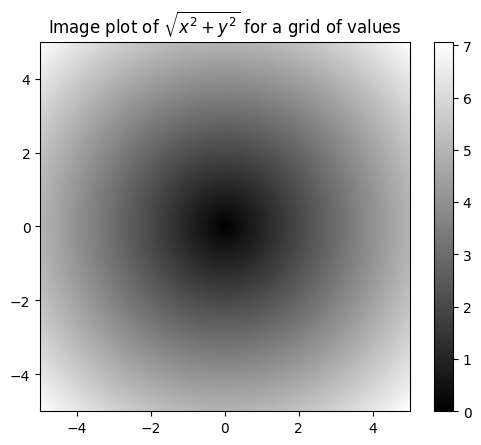

In [44]:
import matplotlib.pyplot as plt
plt.imshow(z, cmap=plt.cm.gray, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

In [ ]:
plt.close("all")
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])
result = [(x if c else y)
          for x, y, c in zip(xarr, yarr, cond)]
result

[1.1, 2.2, 1.3, 1.4, 2.5]

instead of ^^ slow python version, for large datasets use np

In [54]:
result = np.where(cond, xarr, yarr)
result
arr = rng.standard_normal((4, 4))
arr
arr > 0
np.where(arr > 0, 2, -2)
np.where(arr > 0, 2, arr) #set only positive values to 2, negative values remain unchanged

array([[ 2.        , -0.65350565, -0.81188688, -0.02553817],
       [ 2.        ,  2.        ,  2.        ,  2.        ],
       [ 2.        ,  2.        , -1.12296158, -1.97524767],
       [-0.42515005, -1.14907382,  2.        , -0.15847686]])